Loading Patient Vault...
Total rows: 706472

Original cardinality:
  PRINC_DIAG_CODE: 11346 unique values
  PAT_ZIP:         1740 unique values

Applying variable grouping...

New cardinality:
  PRINC_DIAG_CODE: 20 unique values
  PAT_ZIP:         72 unique values

PRINC_DIAG_CODE distribution:
PRINC_DIAG_CODE
CIRCULATORY        96036
HEALTH_SERVICES    94808
PREGNANCY          92462
RESPIRATORY        60894
DIGESTIVE          54676
INFECTIOUS         51284
INJURY             49545
MUSCULOSKELETAL    34405
MENTAL             33571
ENDOCRINE          28480
GENITOURINARY      27689
NEOPLASMS          19375
NERVOUS            18801
SYMPTOMS           15720
BLOOD_NEOPLASM     12357
SKIN               10461
PERINATAL           2543
CONGENITAL          2034
EYE_EAR             1330
OTHER                  1

PAT_ZIP top 20 regions:
PAT_ZIP
ZIP3_770    70443
ZIP3_750    49737
ZIP3_782    41640
ZIP3_785    35540
ZIP3_773    33212
ZIP3_775    32472
ZIP3_752    31814
ZIP3_760    28664
ZIP3_761   

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

  Run 1/1 done in 25.9s | Total: 26s | ETA: 0s

All 1 runs completed in 25.9s (25.9s per run)

  MARKOV BLANKET STABILITY REPORT  (1 bootstrap runs)
  Method: Hill Climbing + BIC (with grouped variables)
Variable                  Clinical (LOS)     Financial (TC)    
-----------------------------------------------------------------
CARE_TYPE                 1/1 (100%)         0/1 (0%)          
EMERGENCY_DEPT_FLAG       1/1 (100%)         1/1 (100%)        
ETHNICITY                 0/1 (0%)           1/1 (100%)        
FIRST_PAYMENT_SRC         0/1 (0%)           1/1 (100%)        
PAT_AGE                   0/1 (0%)           0/1 (0%)          
PAT_STATUS                1/1 (100%)         0/1 (0%)          
PAT_ZIP                   0/1 (0%)           0/1 (0%)           ***
PRINC_DIAG_CODE           1/1 (100%)         1/1 (100%)         ***
RACE                      0/1 (0%)           0/1 (0%)          
SECONDARY_PAYMENT_SRC     0/1 (0%)           1/1 (100%)        
SEX_CODE          

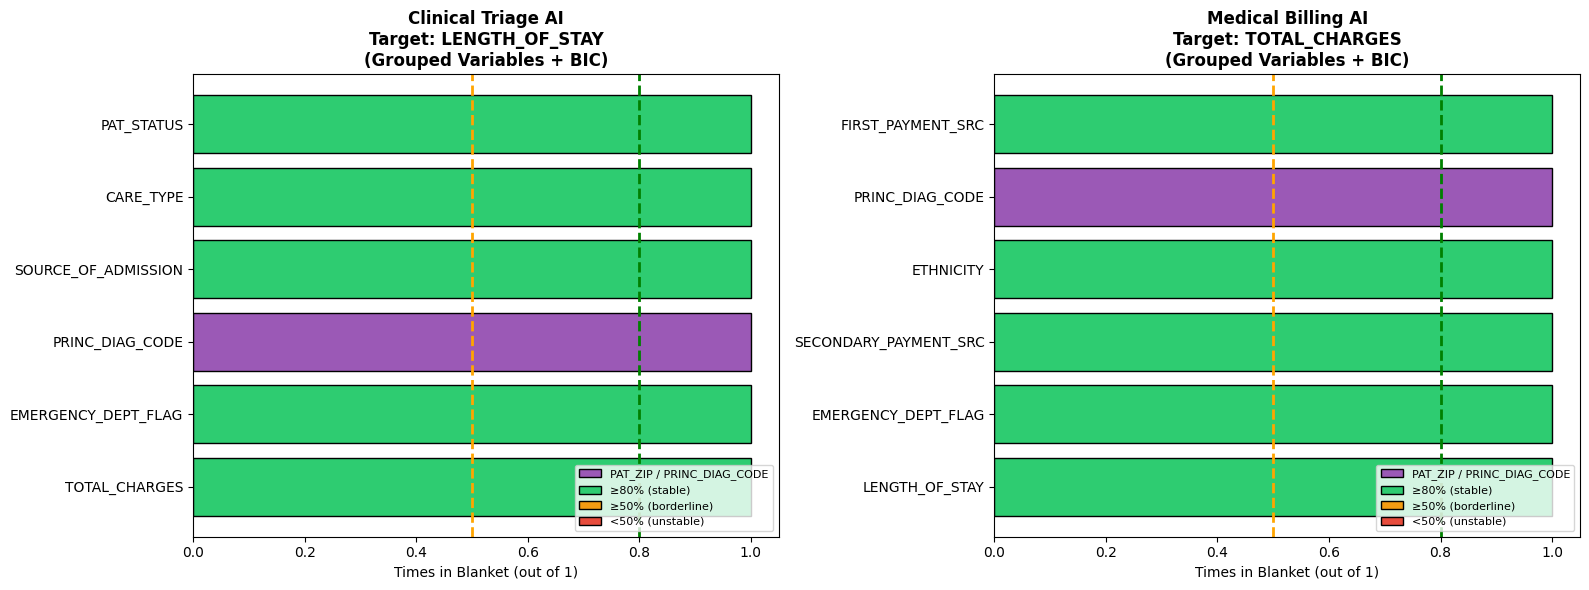

Stability chart saved as 'markov_blanket_stability_grouped.png'


  PREDICTION VALIDATION (Random Forest, 5-fold CV)

Running 5-fold cross-validation...


  Clinical Triage AI
  Target: LENGTH_OF_STAY
  Blanket vars: ['TOTAL_CHARGES', 'EMERGENCY_DEPT_FLAG', 'PRINC_DIAG_CODE', 'SOURCE_OF_ADMISSION', 'CARE_TYPE', 'PAT_STATUS']
  ---
  ALL features (13 vars):     0.5554 (+/- 0.0068)
  BLANKET only  (6 vars):     0.5787 (+/- 0.0048)
  Accuracy drop:                  -0.0233
  Features eliminated:            7
  >>> MINIMAL DROP — blanket is sufficient for data minimization

  Medical Billing AI
  Target: TOTAL_CHARGES
  Blanket vars: ['LENGTH_OF_STAY', 'EMERGENCY_DEPT_FLAG', 'SECONDARY_PAYMENT_SRC', 'ETHNICITY', 'PRINC_DIAG_CODE', 'FIRST_PAYMENT_SRC']
  ---
  ALL features (13 vars):     0.5906 (+/- 0.0034)
  BLANKET only  (6 vars):     0.5566 (+/- 0.0024)
  Accuracy drop:                  0.0340
  Features eliminated:            7
  >>> SMALL DROP — blanket captures most of the signal


  

In [2]:
import pandas as pd
import numpy as np
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# ICD-10 CHAPTER MAPPING
# ==========================================
# Maps first character (and sometimes range) of ICD-10 codes
# to their clinical chapter. This dramatically reduces cardinality
# from hundreds of codes to ~20 categories.

def map_icd10_chapter(code):
    """Map an ICD-10 code to its clinical chapter."""
    if pd.isna(code) or str(code).strip() == '':
        return 'UNKNOWN'
    
    code = str(code).strip().upper()
    
    # Get first character
    first = code[0] if len(code) > 0 else '?'
    
    # Try to get numeric portion after the letter for finer mapping
    icd_chapters = {
        'A': 'INFECTIOUS',        # A00-B99: Infectious/parasitic diseases
        'B': 'INFECTIOUS',
        'C': 'NEOPLASMS',         # C00-D49: Neoplasms
        'D': 'BLOOD_NEOPLASM',    # D50-D89: Blood diseases (overlap with neoplasms)
        'E': 'ENDOCRINE',         # E00-E89: Endocrine/metabolic
        'F': 'MENTAL',            # F01-F99: Mental/behavioral
        'G': 'NERVOUS',           # G00-G99: Nervous system
        'H': 'EYE_EAR',           # H00-H95: Eye and ear
        'I': 'CIRCULATORY',       # I00-I99: Circulatory system
        'J': 'RESPIRATORY',       # J00-J99: Respiratory system
        'K': 'DIGESTIVE',         # K00-K95: Digestive system
        'L': 'SKIN',              # L00-L99: Skin
        'M': 'MUSCULOSKELETAL',   # M00-M99: Musculoskeletal
        'N': 'GENITOURINARY',     # N00-N99: Genitourinary
        'O': 'PREGNANCY',         # O00-O9A: Pregnancy/childbirth
        'P': 'PERINATAL',         # P00-P96: Perinatal conditions
        'Q': 'CONGENITAL',        # Q00-Q99: Congenital malformations
        'R': 'SYMPTOMS',          # R00-R99: Symptoms/signs (not elsewhere classified)
        'S': 'INJURY',            # S00-T88: Injury/poisoning
        'T': 'INJURY',
        'V': 'EXTERNAL_CAUSES',   # V00-Y99: External causes
        'W': 'EXTERNAL_CAUSES',
        'X': 'EXTERNAL_CAUSES',
        'Y': 'EXTERNAL_CAUSES',
        'Z': 'HEALTH_SERVICES',   # Z00-Z99: Factors influencing health status
        'U': 'SPECIAL_CODES',     # U00-U85: Special purpose codes
    }
    
    return icd_chapters.get(first, 'OTHER')


def bin_zip_to_region(zip_code):
    """Bin ZIP code to 3-digit prefix (ZIP3 region)."""
    if pd.isna(zip_code) or str(zip_code).strip() == '':
        return 'UNKNOWN'
    
    zip_str = str(zip_code).strip()
    
    # Handle ZIP codes that might be numeric
    # Pad with leading zeros if needed (e.g., NJ zips start with 0)
    if zip_str.replace('.', '').replace('-', '').isdigit():
        zip_str = zip_str.split('.')[0].split('-')[0]  # Remove decimals or ZIP+4
        zip_str = zip_str.zfill(5)  # Pad to 5 digits
    
    if len(zip_str) >= 3:
        return 'ZIP3_' + zip_str[:3]
    else:
        return 'UNKNOWN'


# ==========================================
# 1. LOAD AND PREPROCESS
# ==========================================
print("Loading Patient Vault...")
df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")
df_vault = df_vault.drop(columns=["RECORD_ID"])
print(f"Total rows: {len(df_vault)}")

# Show original cardinality
print(f"\nOriginal cardinality:")
print(f"  PRINC_DIAG_CODE: {df_vault['PRINC_DIAG_CODE'].nunique()} unique values")
print(f"  PAT_ZIP:         {df_vault['PAT_ZIP'].nunique()} unique values")

# Apply grouping
print("\nApplying variable grouping...")
df_vault['PRINC_DIAG_CODE'] = df_vault['PRINC_DIAG_CODE'].apply(map_icd10_chapter)
df_vault['PAT_ZIP'] = df_vault['PAT_ZIP'].apply(bin_zip_to_region)

print(f"\nNew cardinality:")
print(f"  PRINC_DIAG_CODE: {df_vault['PRINC_DIAG_CODE'].nunique()} unique values")
print(f"  PAT_ZIP:         {df_vault['PAT_ZIP'].nunique()} unique values")

print(f"\nPRINC_DIAG_CODE distribution:")
print(df_vault['PRINC_DIAG_CODE'].value_counts().to_string())
print(f"\nPAT_ZIP top 20 regions:")
print(df_vault['PAT_ZIP'].value_counts().head(20).to_string())

# ==========================================
# 2. BOOTSTRAP WITH HILL CLIMBING + BIC
# ==========================================
N_RUNS = 1
SAMPLE_SIZE = 706000
STABILITY_THRESHOLD = 0.80

clinical_counter = Counter()
financial_counter = Counter()

print(f"\n{'='*65}")
print(f"  RUNNING HILL CLIMBING + BIC WITH GROUPED VARIABLES")
print(f"  {N_RUNS} bootstrap runs, {SAMPLE_SIZE} samples each")
print(f"{'='*65}\n")

import time
total_start = time.time()

for i in range(N_RUNS):
    run_start = time.time()
    
    df_sample = df_vault.sample(n=SAMPLE_SIZE, replace=True, random_state=i).copy()

    df_sample['TOTAL_CHARGES'] = pd.qcut(
        df_sample['TOTAL_CHARGES'], q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    )
    df_sample['LENGTH_OF_STAY'] = pd.qcut(
        df_sample['LENGTH_OF_STAY'], q=4,
        labels=['Short', 'Medium', 'Long', 'Extended'],
        duplicates='drop'
    )
    df_sample = df_sample.astype(str)

    try:
        hc = HillClimbSearch(df_sample)
        best_model = hc.estimate(scoring_method="bic-d")
        bn = DiscreteBayesianNetwork(best_model.edges())

        mb_clinical = bn.get_markov_blanket("LENGTH_OF_STAY")
        mb_financial = bn.get_markov_blanket("TOTAL_CHARGES")

        for var in mb_clinical:
            clinical_counter[var] += 1
        for var in mb_financial:
            financial_counter[var] += 1

    except Exception as e:
        print(f"  Run {i + 1} failed: {e}")
        continue

    run_elapsed = time.time() - run_start
    elapsed_total = time.time() - total_start
    avg_per_run = elapsed_total / (i + 1)
    eta = avg_per_run * (N_RUNS - i - 1)

    if (i + 1) % 5 == 0 or i == 0:
        print(f"  Run {i+1}/{N_RUNS} done in {run_elapsed:.1f}s "
              f"| Total: {elapsed_total:.0f}s | ETA: {eta:.0f}s")

total_elapsed = time.time() - total_start
print(f"\nAll {N_RUNS} runs completed in {total_elapsed:.1f}s "
      f"({total_elapsed/N_RUNS:.1f}s per run)")

# ==========================================
# 3. STABILITY REPORT
# ==========================================
all_vars = sorted([c for c in df_vault.columns if c not in ["LENGTH_OF_STAY", "TOTAL_CHARGES"]])

print("\n" + "=" * 65)
print(f"  MARKOV BLANKET STABILITY REPORT  ({N_RUNS} bootstrap runs)")
print(f"  Method: Hill Climbing + BIC (with grouped variables)")
print("=" * 65)
print(f"{'Variable':<25} {'Clinical (LOS)':<18} {'Financial (TC)':<18}")
print("-" * 65)
for var in all_vars:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    c_pct = f"{c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%)"
    f_pct = f"{f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%)"
    # Highlight the variables we fixed
    marker = " ***" if var in ["PRINC_DIAG_CODE", "PAT_ZIP"] else ""
    print(f"{var:<25} {c_pct:<18} {f_pct:<18}{marker}")
print("-" * 65)

# ==========================================
# 4. EXTRACT STABLE BLANKETS
# ==========================================
threshold_count = int(N_RUNS * STABILITY_THRESHOLD)

clinical_blanket = [var for var, count in clinical_counter.items() if count >= threshold_count]
financial_blanket = [var for var, count in financial_counter.items() if count >= threshold_count]

print(f"\nStable Clinical Blanket (80%+):  {clinical_blanket}")
print(f"Stable Financial Blanket (80%+): {financial_blanket}")

# Check if our target variables made it in
for var in ["PRINC_DIAG_CODE", "PAT_ZIP"]:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    in_clinical = var in clinical_blanket
    in_financial = var in financial_blanket
    print(f"\n  {var}:")
    print(f"    Clinical: {c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%) — {'IN BLANKET' if in_clinical else 'not in blanket'}")
    print(f"    Financial: {f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%) — {'IN BLANKET' if in_financial else 'not in blanket'}")

if not clinical_blanket:
    print("\nWARNING: No variables hit 80% for Clinical. Lowering threshold to 50%.")
    clinical_blanket = [var for var, count in clinical_counter.items() if count >= N_RUNS * 0.5]
if not financial_blanket:
    print("WARNING: No variables hit 80% for Financial. Lowering threshold to 50%.")
    financial_blanket = [var for var, count in financial_counter.items() if count >= N_RUNS * 0.5]

# ==========================================
# 5. STABILITY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, counter, title_task, title_target in [
    (axes[0], clinical_counter, "Clinical Triage AI", "LENGTH_OF_STAY"),
    (axes[1], financial_counter, "Medical Billing AI", "TOTAL_CHARGES")
]:
    if counter:
        vars_sorted = sorted(counter.keys(), key=lambda x: counter[x], reverse=True)
        counts = [counter[v] for v in vars_sorted]
        
        colors = []
        for v, c in zip(vars_sorted, counts):
            if v in ["PRINC_DIAG_CODE", "PAT_ZIP"]:
                colors.append('#9b59b6')  # Purple for our target variables
            elif c >= N_RUNS * 0.8:
                colors.append('#2ecc71')
            elif c >= N_RUNS * 0.5:
                colors.append('#f39c12')
            else:
                colors.append('#e74c3c')
        
        bars = ax.barh(vars_sorted, counts, color=colors, edgecolor='black')
        ax.axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
        ax.axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
        ax.set_xlabel(f'Times in Blanket (out of {N_RUNS})')
        ax.set_title(f"{title_task}\nTarget: {title_target}\n(Grouped Variables + BIC)", fontweight='bold')
        
        # Custom legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#9b59b6', edgecolor='black', label='PAT_ZIP / PRINC_DIAG_CODE'),
            Patch(facecolor='#2ecc71', edgecolor='black', label='≥80% (stable)'),
            Patch(facecolor='#f39c12', edgecolor='black', label='≥50% (borderline)'),
            Patch(facecolor='#e74c3c', edgecolor='black', label='<50% (unstable)'),
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig("markov_blanket_stability_grouped.png", dpi=150, bbox_inches='tight')
plt.show()
print("Stability chart saved as 'markov_blanket_stability_grouped.png'")

# ==========================================
# 6. PREDICTION VALIDATION
# ==========================================
print("\n\n" + "=" * 65)
print("  PREDICTION VALIDATION (Random Forest, 5-fold CV)")
print("=" * 65)

df_pred = df_vault.sample(n=50000, random_state=42).copy()

df_pred['TOTAL_CHARGES'] = pd.qcut(df_pred['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_pred['LENGTH_OF_STAY'] = pd.qcut(df_pred['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

for col in df_pred.columns:
    le = LabelEncoder()
    df_pred[col] = le.fit_transform(df_pred[col].astype(str))

def compare_models(df, target, blanket_features, task_name):
    if not blanket_features:
        print(f"\n  {task_name}: WARNING — empty blanket, skipping.")
        return None, None

    all_features = [c for c in df.columns if c != target]
    y = df[target]

    X_all = df[all_features]
    scores_all = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_all, y, cv=5, scoring='accuracy'
    )

    X_blanket = df[blanket_features]
    scores_blanket = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_blanket, y, cv=5, scoring='accuracy'
    )

    drop = scores_all.mean() - scores_blanket.mean()

    print(f"\n  {task_name}")
    print(f"  Target: {target}")
    print(f"  Blanket vars: {blanket_features}")
    print(f"  ---")
    print(f"  ALL features ({len(all_features)} vars):     {scores_all.mean():.4f} (+/- {scores_all.std():.4f})")
    print(f"  BLANKET only  ({len(blanket_features)} vars):     {scores_blanket.mean():.4f} (+/- {scores_blanket.std():.4f})")
    print(f"  Accuracy drop:                  {drop:.4f}")
    print(f"  Features eliminated:            {len(all_features) - len(blanket_features)}")

    if drop < 0.02:
        print(f"  >>> MINIMAL DROP — blanket is sufficient for data minimization")
    elif drop < 0.05:
        print(f"  >>> SMALL DROP — blanket captures most of the signal")
    else:
        print(f"  >>> NOTABLE DROP — consider adding borderline (50%+) variables")

    return scores_all.mean(), scores_blanket.mean()

print("\nRunning 5-fold cross-validation...\n")

all_acc_c, blanket_acc_c = compare_models(df_pred, "LENGTH_OF_STAY", clinical_blanket, "Clinical Triage AI")
all_acc_f, blanket_acc_f = compare_models(df_pred, "TOTAL_CHARGES", financial_blanket, "Medical Billing AI")

# ==========================================
# 7. FINAL SUMMARY
# ==========================================
print("\n\n" + "=" * 65)
print("  FINAL SUMMARY: GROUPED VARIABLES")
print("=" * 65)

print(f"\n  Variable transformations applied:")
print(f"    PRINC_DIAG_CODE: Raw ICD-10 codes → Clinical chapters (~20 categories)")
print(f"    PAT_ZIP: Raw ZIP codes → 3-digit regions")

print(f"\n  Clinical AI (LENGTH_OF_STAY):")
print(f"    Blanket: {clinical_blanket}")
print(f"    PRINC_DIAG_CODE in blanket: {'YES' if 'PRINC_DIAG_CODE' in clinical_blanket else 'NO'}")
print(f"    PAT_ZIP in blanket: {'YES' if 'PAT_ZIP' in clinical_blanket else 'NO'}")
if blanket_acc_c is not None:
    print(f"    Accuracy: {blanket_acc_c:.4f} vs {all_acc_c:.4f} (all features)")

print(f"\n  Financial AI (TOTAL_CHARGES):")
print(f"    Blanket: {financial_blanket}")
print(f"    PRINC_DIAG_CODE in blanket: {'YES' if 'PRINC_DIAG_CODE' in financial_blanket else 'NO'}")
print(f"    PAT_ZIP in blanket: {'YES' if 'PAT_ZIP' in financial_blanket else 'NO'}")
if blanket_acc_f is not None:
    print(f"    Accuracy: {blanket_acc_f:.4f} vs {all_acc_f:.4f} (all features)")

print(f"\n  If PRINC_DIAG_CODE and PAT_ZIP now appear in the blankets,")
print(f"  it confirms the original exclusion was due to high cardinality")
print(f"  penalization in BIC, not genuine conditional independence.")
print("=" * 65)

Loading Patient Vault...
Total rows: 706472

Original cardinality:
  PRINC_DIAG_CODE: 11346 unique values
  PAT_ZIP:         1740 unique values

Applying variable grouping...

New cardinality:
  PRINC_DIAG_CODE: 20 unique values
  PAT_ZIP:         72 unique values

PRINC_DIAG_CODE distribution:
PRINC_DIAG_CODE
CIRCULATORY        96036
HEALTH_SERVICES    94808
PREGNANCY          92462
RESPIRATORY        60894
DIGESTIVE          54676
INFECTIOUS         51284
INJURY             49545
MUSCULOSKELETAL    34405
MENTAL             33571
ENDOCRINE          28480
GENITOURINARY      27689
NEOPLASMS          19375
NERVOUS            18801
SYMPTOMS           15720
BLOOD_NEOPLASM     12357
SKIN               10461
PERINATAL           2543
CONGENITAL          2034
EYE_EAR             1330
OTHER                  1

PAT_ZIP top 20 regions:
PAT_ZIP
ZIP3_770    70443
ZIP3_750    49737
ZIP3_782    41640
ZIP3_785    35540
ZIP3_773    33212
ZIP3_775    32472
ZIP3_752    31814
ZIP3_760    28664
ZIP3_761   

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

  Run 1/100 done in 3.6s | Total: 4s | ETA: 355s


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

  Run 5/100 done in 3.8s | Total: 18s | ETA: 351s


...

  Run 90/100 done in 15.5s | Total: 613s | ETA: 68s


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

  Run 95/100 done in 16.0s | Total: 692s | ETA: 36s


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

  Run 100/100 done in 3.0s | Total: 728s | ETA: 0s

All 100 runs completed in 728.3s (7.3s per run)

  MARKOV BLANKET STABILITY REPORT  (100 bootstrap runs)
  Method: Hill Climbing + BIC (with grouped variables)
Variable                  Clinical (LOS)     Financial (TC)    
-----------------------------------------------------------------
CARE_TYPE                 7/100 (7%)         0/100 (0%)        
EMERGENCY_DEPT_FLAG       87/100 (87%)       87/100 (87%)      
ETHNICITY                 0/100 (0%)         0/100 (0%)        
FIRST_PAYMENT_SRC         0/100 (0%)         0/100 (0%)        
PAT_AGE                   0/100 (0%)         0/100 (0%)        
PAT_STATUS                0/100 (0%)         0/100 (0%)        
PAT_ZIP                   0/100 (0%)         84/100 (84%)       ***
PRINC_DIAG_CODE           100/100 (100%)     100/100 (100%)     ***
RACE                      0/100 (0%)         0/100 (0%)        
SECONDARY_PAYMENT_SRC     0/100 (0%)         0/100 (0%)        
SEX_CODE  

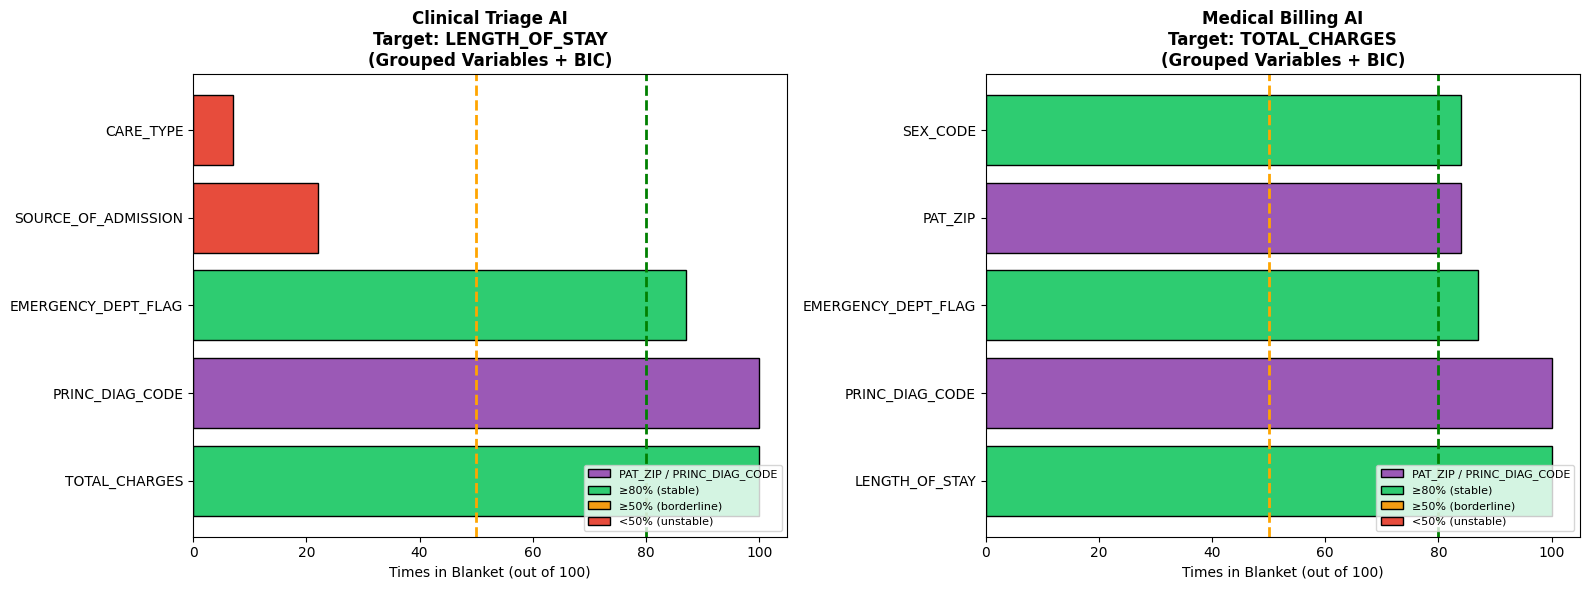

Stability chart saved as 'markov_blanket_stability_grouped.png'


  PREDICTION VALIDATION (Random Forest, 5-fold CV)

Running 5-fold cross-validation...


  Clinical Triage AI
  Target: LENGTH_OF_STAY
  Blanket vars: ['TOTAL_CHARGES', 'EMERGENCY_DEPT_FLAG', 'PRINC_DIAG_CODE']
  ---
  ALL features (13 vars):     0.5554 (+/- 0.0068)
  BLANKET only  (3 vars):     0.5583 (+/- 0.0032)
  Accuracy drop:                  -0.0030
  Features eliminated:            10
  >>> MINIMAL DROP — blanket is sufficient for data minimization

  Medical Billing AI
  Target: TOTAL_CHARGES
  Blanket vars: ['LENGTH_OF_STAY', 'EMERGENCY_DEPT_FLAG', 'PAT_ZIP', 'SEX_CODE', 'PRINC_DIAG_CODE']
  ---
  ALL features (13 vars):     0.5906 (+/- 0.0034)
  BLANKET only  (5 vars):     0.5511 (+/- 0.0036)
  Accuracy drop:                  0.0395
  Features eliminated:            8
  >>> SMALL DROP — blanket captures most of the signal


  FINAL SUMMARY: GROUPED VARIABLES

  Variable transformations applied:
    PRINC_DIAG_

In [3]:
import pandas as pd
import numpy as np
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# ICD-10 CHAPTER MAPPING
# ==========================================
# Maps first character (and sometimes range) of ICD-10 codes
# to their clinical chapter. This dramatically reduces cardinality
# from hundreds of codes to ~20 categories.

def map_icd10_chapter(code):
    """Map an ICD-10 code to its clinical chapter."""
    if pd.isna(code) or str(code).strip() == '':
        return 'UNKNOWN'
    
    code = str(code).strip().upper()
    
    # Get first character
    first = code[0] if len(code) > 0 else '?'
    
    # Try to get numeric portion after the letter for finer mapping
    icd_chapters = {
        'A': 'INFECTIOUS',        # A00-B99: Infectious/parasitic diseases
        'B': 'INFECTIOUS',
        'C': 'NEOPLASMS',         # C00-D49: Neoplasms
        'D': 'BLOOD_NEOPLASM',    # D50-D89: Blood diseases (overlap with neoplasms)
        'E': 'ENDOCRINE',         # E00-E89: Endocrine/metabolic
        'F': 'MENTAL',            # F01-F99: Mental/behavioral
        'G': 'NERVOUS',           # G00-G99: Nervous system
        'H': 'EYE_EAR',           # H00-H95: Eye and ear
        'I': 'CIRCULATORY',       # I00-I99: Circulatory system
        'J': 'RESPIRATORY',       # J00-J99: Respiratory system
        'K': 'DIGESTIVE',         # K00-K95: Digestive system
        'L': 'SKIN',              # L00-L99: Skin
        'M': 'MUSCULOSKELETAL',   # M00-M99: Musculoskeletal
        'N': 'GENITOURINARY',     # N00-N99: Genitourinary
        'O': 'PREGNANCY',         # O00-O9A: Pregnancy/childbirth
        'P': 'PERINATAL',         # P00-P96: Perinatal conditions
        'Q': 'CONGENITAL',        # Q00-Q99: Congenital malformations
        'R': 'SYMPTOMS',          # R00-R99: Symptoms/signs (not elsewhere classified)
        'S': 'INJURY',            # S00-T88: Injury/poisoning
        'T': 'INJURY',
        'V': 'EXTERNAL_CAUSES',   # V00-Y99: External causes
        'W': 'EXTERNAL_CAUSES',
        'X': 'EXTERNAL_CAUSES',
        'Y': 'EXTERNAL_CAUSES',
        'Z': 'HEALTH_SERVICES',   # Z00-Z99: Factors influencing health status
        'U': 'SPECIAL_CODES',     # U00-U85: Special purpose codes
    }
    
    return icd_chapters.get(first, 'OTHER')


def bin_zip_to_region(zip_code):
    """Bin ZIP code to 3-digit prefix (ZIP3 region)."""
    if pd.isna(zip_code) or str(zip_code).strip() == '':
        return 'UNKNOWN'
    
    zip_str = str(zip_code).strip()
    
    # Handle ZIP codes that might be numeric
    # Pad with leading zeros if needed (e.g., NJ zips start with 0)
    if zip_str.replace('.', '').replace('-', '').isdigit():
        zip_str = zip_str.split('.')[0].split('-')[0]  # Remove decimals or ZIP+4
        zip_str = zip_str.zfill(5)  # Pad to 5 digits
    
    if len(zip_str) >= 3:
        return 'ZIP3_' + zip_str[:3]
    else:
        return 'UNKNOWN'


# ==========================================
# 1. LOAD AND PREPROCESS
# ==========================================
print("Loading Patient Vault...")
df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")
df_vault = df_vault.drop(columns=["RECORD_ID"])
print(f"Total rows: {len(df_vault)}")

# Show original cardinality
print(f"\nOriginal cardinality:")
print(f"  PRINC_DIAG_CODE: {df_vault['PRINC_DIAG_CODE'].nunique()} unique values")
print(f"  PAT_ZIP:         {df_vault['PAT_ZIP'].nunique()} unique values")

# Apply grouping
print("\nApplying variable grouping...")
df_vault['PRINC_DIAG_CODE'] = df_vault['PRINC_DIAG_CODE'].apply(map_icd10_chapter)
df_vault['PAT_ZIP'] = df_vault['PAT_ZIP'].apply(bin_zip_to_region)

print(f"\nNew cardinality:")
print(f"  PRINC_DIAG_CODE: {df_vault['PRINC_DIAG_CODE'].nunique()} unique values")
print(f"  PAT_ZIP:         {df_vault['PAT_ZIP'].nunique()} unique values")

print(f"\nPRINC_DIAG_CODE distribution:")
print(df_vault['PRINC_DIAG_CODE'].value_counts().to_string())
print(f"\nPAT_ZIP top 20 regions:")
print(df_vault['PAT_ZIP'].value_counts().head(20).to_string())

# ==========================================
# 2. BOOTSTRAP WITH HILL CLIMBING + BIC
# ==========================================
N_RUNS = 100
SAMPLE_SIZE = 100000
STABILITY_THRESHOLD = 0.80

clinical_counter = Counter()
financial_counter = Counter()

print(f"\n{'='*65}")
print(f"  RUNNING HILL CLIMBING + BIC WITH GROUPED VARIABLES")
print(f"  {N_RUNS} bootstrap runs, {SAMPLE_SIZE} samples each")
print(f"{'='*65}\n")

import time
total_start = time.time()

for i in range(N_RUNS):
    run_start = time.time()
    
    df_sample = df_vault.sample(n=SAMPLE_SIZE, replace=True, random_state=i).copy()

    df_sample['TOTAL_CHARGES'] = pd.qcut(
        df_sample['TOTAL_CHARGES'], q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    )
    df_sample['LENGTH_OF_STAY'] = pd.qcut(
        df_sample['LENGTH_OF_STAY'], q=4,
        labels=['Short', 'Medium', 'Long', 'Extended'],
        duplicates='drop'
    )
    df_sample = df_sample.astype(str)

    try:
        hc = HillClimbSearch(df_sample)
        best_model = hc.estimate(scoring_method="bic-d")
        bn = DiscreteBayesianNetwork(best_model.edges())

        mb_clinical = bn.get_markov_blanket("LENGTH_OF_STAY")
        mb_financial = bn.get_markov_blanket("TOTAL_CHARGES")

        for var in mb_clinical:
            clinical_counter[var] += 1
        for var in mb_financial:
            financial_counter[var] += 1

    except Exception as e:
        print(f"  Run {i + 1} failed: {e}")
        continue

    run_elapsed = time.time() - run_start
    elapsed_total = time.time() - total_start
    avg_per_run = elapsed_total / (i + 1)
    eta = avg_per_run * (N_RUNS - i - 1)

    if (i + 1) % 5 == 0 or i == 0:
        print(f"  Run {i+1}/{N_RUNS} done in {run_elapsed:.1f}s "
              f"| Total: {elapsed_total:.0f}s | ETA: {eta:.0f}s")

total_elapsed = time.time() - total_start
print(f"\nAll {N_RUNS} runs completed in {total_elapsed:.1f}s "
      f"({total_elapsed/N_RUNS:.1f}s per run)")

# ==========================================
# 3. STABILITY REPORT
# ==========================================
all_vars = sorted([c for c in df_vault.columns if c not in ["LENGTH_OF_STAY", "TOTAL_CHARGES"]])

print("\n" + "=" * 65)
print(f"  MARKOV BLANKET STABILITY REPORT  ({N_RUNS} bootstrap runs)")
print(f"  Method: Hill Climbing + BIC (with grouped variables)")
print("=" * 65)
print(f"{'Variable':<25} {'Clinical (LOS)':<18} {'Financial (TC)':<18}")
print("-" * 65)
for var in all_vars:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    c_pct = f"{c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%)"
    f_pct = f"{f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%)"
    # Highlight the variables we fixed
    marker = " ***" if var in ["PRINC_DIAG_CODE", "PAT_ZIP"] else ""
    print(f"{var:<25} {c_pct:<18} {f_pct:<18}{marker}")
print("-" * 65)

# ==========================================
# 4. EXTRACT STABLE BLANKETS
# ==========================================
threshold_count = int(N_RUNS * STABILITY_THRESHOLD)

clinical_blanket = [var for var, count in clinical_counter.items() if count >= threshold_count]
financial_blanket = [var for var, count in financial_counter.items() if count >= threshold_count]

print(f"\nStable Clinical Blanket (80%+):  {clinical_blanket}")
print(f"Stable Financial Blanket (80%+): {financial_blanket}")

# Check if our target variables made it in
for var in ["PRINC_DIAG_CODE", "PAT_ZIP"]:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    in_clinical = var in clinical_blanket
    in_financial = var in financial_blanket
    print(f"\n  {var}:")
    print(f"    Clinical: {c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%) — {'IN BLANKET' if in_clinical else 'not in blanket'}")
    print(f"    Financial: {f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%) — {'IN BLANKET' if in_financial else 'not in blanket'}")

if not clinical_blanket:
    print("\nWARNING: No variables hit 80% for Clinical. Lowering threshold to 50%.")
    clinical_blanket = [var for var, count in clinical_counter.items() if count >= N_RUNS * 0.5]
if not financial_blanket:
    print("WARNING: No variables hit 80% for Financial. Lowering threshold to 50%.")
    financial_blanket = [var for var, count in financial_counter.items() if count >= N_RUNS * 0.5]

# ==========================================
# 5. STABILITY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, counter, title_task, title_target in [
    (axes[0], clinical_counter, "Clinical Triage AI", "LENGTH_OF_STAY"),
    (axes[1], financial_counter, "Medical Billing AI", "TOTAL_CHARGES")
]:
    if counter:
        vars_sorted = sorted(counter.keys(), key=lambda x: counter[x], reverse=True)
        counts = [counter[v] for v in vars_sorted]
        
        colors = []
        for v, c in zip(vars_sorted, counts):
            if v in ["PRINC_DIAG_CODE", "PAT_ZIP"]:
                colors.append('#9b59b6')  # Purple for our target variables
            elif c >= N_RUNS * 0.8:
                colors.append('#2ecc71')
            elif c >= N_RUNS * 0.5:
                colors.append('#f39c12')
            else:
                colors.append('#e74c3c')
        
        bars = ax.barh(vars_sorted, counts, color=colors, edgecolor='black')
        ax.axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
        ax.axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
        ax.set_xlabel(f'Times in Blanket (out of {N_RUNS})')
        ax.set_title(f"{title_task}\nTarget: {title_target}\n(Grouped Variables + BIC)", fontweight='bold')
        
        # Custom legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#9b59b6', edgecolor='black', label='PAT_ZIP / PRINC_DIAG_CODE'),
            Patch(facecolor='#2ecc71', edgecolor='black', label='≥80% (stable)'),
            Patch(facecolor='#f39c12', edgecolor='black', label='≥50% (borderline)'),
            Patch(facecolor='#e74c3c', edgecolor='black', label='<50% (unstable)'),
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig("markov_blanket_stability_grouped.png", dpi=150, bbox_inches='tight')
plt.show()
print("Stability chart saved as 'markov_blanket_stability_grouped.png'")

# ==========================================
# 6. PREDICTION VALIDATION
# ==========================================
print("\n\n" + "=" * 65)
print("  PREDICTION VALIDATION (Random Forest, 5-fold CV)")
print("=" * 65)

df_pred = df_vault.sample(n=50000, random_state=42).copy()

df_pred['TOTAL_CHARGES'] = pd.qcut(df_pred['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_pred['LENGTH_OF_STAY'] = pd.qcut(df_pred['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

for col in df_pred.columns:
    le = LabelEncoder()
    df_pred[col] = le.fit_transform(df_pred[col].astype(str))

def compare_models(df, target, blanket_features, task_name):
    if not blanket_features:
        print(f"\n  {task_name}: WARNING — empty blanket, skipping.")
        return None, None

    all_features = [c for c in df.columns if c != target]
    y = df[target]

    X_all = df[all_features]
    scores_all = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_all, y, cv=5, scoring='accuracy'
    )

    X_blanket = df[blanket_features]
    scores_blanket = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_blanket, y, cv=5, scoring='accuracy'
    )

    drop = scores_all.mean() - scores_blanket.mean()

    print(f"\n  {task_name}")
    print(f"  Target: {target}")
    print(f"  Blanket vars: {blanket_features}")
    print(f"  ---")
    print(f"  ALL features ({len(all_features)} vars):     {scores_all.mean():.4f} (+/- {scores_all.std():.4f})")
    print(f"  BLANKET only  ({len(blanket_features)} vars):     {scores_blanket.mean():.4f} (+/- {scores_blanket.std():.4f})")
    print(f"  Accuracy drop:                  {drop:.4f}")
    print(f"  Features eliminated:            {len(all_features) - len(blanket_features)}")

    if drop < 0.02:
        print(f"  >>> MINIMAL DROP — blanket is sufficient for data minimization")
    elif drop < 0.05:
        print(f"  >>> SMALL DROP — blanket captures most of the signal")
    else:
        print(f"  >>> NOTABLE DROP — consider adding borderline (50%+) variables")

    return scores_all.mean(), scores_blanket.mean()

print("\nRunning 5-fold cross-validation...\n")

all_acc_c, blanket_acc_c = compare_models(df_pred, "LENGTH_OF_STAY", clinical_blanket, "Clinical Triage AI")
all_acc_f, blanket_acc_f = compare_models(df_pred, "TOTAL_CHARGES", financial_blanket, "Medical Billing AI")

# ==========================================
# 7. FINAL SUMMARY
# ==========================================
print("\n\n" + "=" * 65)
print("  FINAL SUMMARY: GROUPED VARIABLES")
print("=" * 65)

print(f"\n  Variable transformations applied:")
print(f"    PRINC_DIAG_CODE: Raw ICD-10 codes → Clinical chapters (~20 categories)")
print(f"    PAT_ZIP: Raw ZIP codes → 3-digit regions")

print(f"\n  Clinical AI (LENGTH_OF_STAY):")
print(f"    Blanket: {clinical_blanket}")
print(f"    PRINC_DIAG_CODE in blanket: {'YES' if 'PRINC_DIAG_CODE' in clinical_blanket else 'NO'}")
print(f"    PAT_ZIP in blanket: {'YES' if 'PAT_ZIP' in clinical_blanket else 'NO'}")
if blanket_acc_c is not None:
    print(f"    Accuracy: {blanket_acc_c:.4f} vs {all_acc_c:.4f} (all features)")

print(f"\n  Financial AI (TOTAL_CHARGES):")
print(f"    Blanket: {financial_blanket}")
print(f"    PRINC_DIAG_CODE in blanket: {'YES' if 'PRINC_DIAG_CODE' in financial_blanket else 'NO'}")
print(f"    PAT_ZIP in blanket: {'YES' if 'PAT_ZIP' in financial_blanket else 'NO'}")
if blanket_acc_f is not None:
    print(f"    Accuracy: {blanket_acc_f:.4f} vs {all_acc_f:.4f} (all features)")

print(f"\n  If PRINC_DIAG_CODE and PAT_ZIP now appear in the blankets,")
print(f"  it confirms the original exclusion was due to high cardinality")
print(f"  penalization in BIC, not genuine conditional independence.")
print("=" * 65)

In [ ]:
import pandas as pd
import numpy as np
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# ICD-10 CHAPTER MAPPING
# ==========================================
# Maps first character (and sometimes range) of ICD-10 codes
# to their clinical chapter. This dramatically reduces cardinality
# from hundreds of codes to ~20 categories.

def map_icd10_chapter(code):
    """Map an ICD-10 code to its clinical chapter."""
    if pd.isna(code) or str(code).strip() == '':
        return 'UNKNOWN'
    
    code = str(code).strip().upper()
    
    # Get first character
    first = code[0] if len(code) > 0 else '?'
    
    # Try to get numeric portion after the letter for finer mapping
    icd_chapters = {
        'A': 'INFECTIOUS',        # A00-B99: Infectious/parasitic diseases
        'B': 'INFECTIOUS',
        'C': 'NEOPLASMS',         # C00-D49: Neoplasms
        'D': 'BLOOD_NEOPLASM',    # D50-D89: Blood diseases (overlap with neoplasms)
        'E': 'ENDOCRINE',         # E00-E89: Endocrine/metabolic
        'F': 'MENTAL',            # F01-F99: Mental/behavioral
        'G': 'NERVOUS',           # G00-G99: Nervous system
        'H': 'EYE_EAR',           # H00-H95: Eye and ear
        'I': 'CIRCULATORY',       # I00-I99: Circulatory system
        'J': 'RESPIRATORY',       # J00-J99: Respiratory system
        'K': 'DIGESTIVE',         # K00-K95: Digestive system
        'L': 'SKIN',              # L00-L99: Skin
        'M': 'MUSCULOSKELETAL',   # M00-M99: Musculoskeletal
        'N': 'GENITOURINARY',     # N00-N99: Genitourinary
        'O': 'PREGNANCY',         # O00-O9A: Pregnancy/childbirth
        'P': 'PERINATAL',         # P00-P96: Perinatal conditions
        'Q': 'CONGENITAL',        # Q00-Q99: Congenital malformations
        'R': 'SYMPTOMS',          # R00-R99: Symptoms/signs (not elsewhere classified)
        'S': 'INJURY',            # S00-T88: Injury/poisoning
        'T': 'INJURY',
        'V': 'EXTERNAL_CAUSES',   # V00-Y99: External causes
        'W': 'EXTERNAL_CAUSES',
        'X': 'EXTERNAL_CAUSES',
        'Y': 'EXTERNAL_CAUSES',
        'Z': 'HEALTH_SERVICES',   # Z00-Z99: Factors influencing health status
        'U': 'SPECIAL_CODES',     # U00-U85: Special purpose codes
    }
    
    return icd_chapters.get(first, 'OTHER')


def bin_zip_to_region(zip_code):
    """Bin ZIP code to 3-digit prefix (ZIP3 region)."""
    if pd.isna(zip_code) or str(zip_code).strip() == '':
        return 'UNKNOWN'
    
    zip_str = str(zip_code).strip()
    
    # Handle ZIP codes that might be numeric
    # Pad with leading zeros if needed (e.g., NJ zips start with 0)
    if zip_str.replace('.', '').replace('-', '').isdigit():
        zip_str = zip_str.split('.')[0].split('-')[0]  # Remove decimals or ZIP+4
        zip_str = zip_str.zfill(5)  # Pad to 5 digits
    
    if len(zip_str) >= 3:
        return 'ZIP3_' + zip_str[:3]
    else:
        return 'UNKNOWN'


# ==========================================
# 1. LOAD AND PREPROCESS
# ==========================================
print("Loading Patient Vault...")
df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")
df_vault = df_vault.drop(columns=["RECORD_ID"])
print(f"Total rows: {len(df_vault)}")

# Show original cardinality
print(f"\nOriginal cardinality:")
print(f"  PRINC_DIAG_CODE: {df_vault['PRINC_DIAG_CODE'].nunique()} unique values")
print(f"  PAT_ZIP:         {df_vault['PAT_ZIP'].nunique()} unique values")

# Apply grouping
print("\nApplying variable grouping...")
df_vault['PRINC_DIAG_CODE'] = df_vault['PRINC_DIAG_CODE'].apply(map_icd10_chapter)
df_vault['PAT_ZIP'] = df_vault['PAT_ZIP'].apply(bin_zip_to_region)

print(f"\nNew cardinality:")
print(f"  PRINC_DIAG_CODE: {df_vault['PRINC_DIAG_CODE'].nunique()} unique values")
print(f"  PAT_ZIP:         {df_vault['PAT_ZIP'].nunique()} unique values")

print(f"\nPRINC_DIAG_CODE distribution:")
print(df_vault['PRINC_DIAG_CODE'].value_counts().to_string())
print(f"\nPAT_ZIP top 20 regions:")
print(df_vault['PAT_ZIP'].value_counts().head(20).to_string())

# ==========================================
# 2. BOOTSTRAP WITH HILL CLIMBING + BIC
# ==========================================
N_RUNS = 100
SAMPLE_SIZE = 100000
STABILITY_THRESHOLD = 0.80

clinical_counter = Counter()
financial_counter = Counter()

print(f"\n{'='*65}")
print(f"  RUNNING HILL CLIMBING + BIC WITH GROUPED VARIABLES")
print(f"  {N_RUNS} bootstrap runs, {SAMPLE_SIZE} samples each")
print(f"{'='*65}\n")

import time
total_start = time.time()

for i in range(N_RUNS):
    run_start = time.time()
    
    df_sample = df_vault.sample(n=SAMPLE_SIZE, replace=True, random_state=i).copy()

    df_sample['TOTAL_CHARGES'] = pd.qcut(
        df_sample['TOTAL_CHARGES'], q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    )
    df_sample['LENGTH_OF_STAY'] = pd.qcut(
        df_sample['LENGTH_OF_STAY'], q=4,
        labels=['Short', 'Medium', 'Long', 'Extended'],
        duplicates='drop'
    )
    df_sample = df_sample.astype(str)

    try:
        hc = HillClimbSearch(df_sample)
        best_model = hc.estimate(scoring_method="bic-d")
        bn = DiscreteBayesianNetwork(best_model.edges())

        mb_clinical = bn.get_markov_blanket("LENGTH_OF_STAY")
        mb_financial = bn.get_markov_blanket("TOTAL_CHARGES")

        for var in mb_clinical:
            clinical_counter[var] += 1
        for var in mb_financial:
            financial_counter[var] += 1

    except Exception as e:
        print(f"  Run {i + 1} failed: {e}")
        continue

    run_elapsed = time.time() - run_start
    elapsed_total = time.time() - total_start
    avg_per_run = elapsed_total / (i + 1)
    eta = avg_per_run * (N_RUNS - i - 1)

    if (i + 1) % 5 == 0 or i == 0:
        print(f"  Run {i+1}/{N_RUNS} done in {run_elapsed:.1f}s "
              f"| Total: {elapsed_total:.0f}s | ETA: {eta:.0f}s")

total_elapsed = time.time() - total_start
print(f"\nAll {N_RUNS} runs completed in {total_elapsed:.1f}s "
      f"({total_elapsed/N_RUNS:.1f}s per run)")

# ==========================================
# 3. STABILITY REPORT
# ==========================================
all_vars = sorted([c for c in df_vault.columns if c not in ["LENGTH_OF_STAY", "TOTAL_CHARGES"]])

print("\n" + "=" * 65)
print(f"  MARKOV BLANKET STABILITY REPORT  ({N_RUNS} bootstrap runs)")
print(f"  Method: Hill Climbing + BIC (with grouped variables)")
print("=" * 65)
print(f"{'Variable':<25} {'Clinical (LOS)':<18} {'Financial (TC)':<18}")
print("-" * 65)
for var in all_vars:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    c_pct = f"{c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%)"
    f_pct = f"{f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%)"
    # Highlight the variables we fixed
    marker = " ***" if var in ["PRINC_DIAG_CODE", "PAT_ZIP"] else ""
    print(f"{var:<25} {c_pct:<18} {f_pct:<18}{marker}")
print("-" * 65)

# ==========================================
# 4. EXTRACT STABLE BLANKETS
# ==========================================
threshold_count = int(N_RUNS * STABILITY_THRESHOLD)

clinical_blanket = [var for var, count in clinical_counter.items() if count >= threshold_count]
financial_blanket = [var for var, count in financial_counter.items() if count >= threshold_count]

print(f"\nStable Clinical Blanket (80%+):  {clinical_blanket}")
print(f"Stable Financial Blanket (80%+): {financial_blanket}")

# Check if our target variables made it in
for var in ["PRINC_DIAG_CODE", "PAT_ZIP"]:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    in_clinical = var in clinical_blanket
    in_financial = var in financial_blanket
    print(f"\n  {var}:")
    print(f"    Clinical: {c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%) — {'IN BLANKET' if in_clinical else 'not in blanket'}")
    print(f"    Financial: {f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%) — {'IN BLANKET' if in_financial else 'not in blanket'}")

if not clinical_blanket:
    print("\nWARNING: No variables hit 80% for Clinical. Lowering threshold to 50%.")
    clinical_blanket = [var for var, count in clinical_counter.items() if count >= N_RUNS * 0.5]
if not financial_blanket:
    print("WARNING: No variables hit 80% for Financial. Lowering threshold to 50%.")
    financial_blanket = [var for var, count in financial_counter.items() if count >= N_RUNS * 0.5]

# ==========================================
# 5. STABILITY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, counter, title_task, title_target in [
    (axes[0], clinical_counter, "Clinical Triage AI", "LENGTH_OF_STAY"),
    (axes[1], financial_counter, "Medical Billing AI", "TOTAL_CHARGES")
]:
    if counter:
        vars_sorted = sorted(counter.keys(), key=lambda x: counter[x], reverse=True)
        counts = [counter[v] for v in vars_sorted]
        
        colors = []
        for v, c in zip(vars_sorted, counts):
            if v in ["PRINC_DIAG_CODE", "PAT_ZIP"]:
                colors.append('#9b59b6')  # Purple for our target variables
            elif c >= N_RUNS * 0.8:
                colors.append('#2ecc71')
            elif c >= N_RUNS * 0.5:
                colors.append('#f39c12')
            else:
                colors.append('#e74c3c')
        
        bars = ax.barh(vars_sorted, counts, color=colors, edgecolor='black')
        ax.axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
        ax.axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
        ax.set_xlabel(f'Times in Blanket (out of {N_RUNS})')
        ax.set_title(f"{title_task}\nTarget: {title_target}\n(Grouped Variables + BIC)", fontweight='bold')
        
        # Custom legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#9b59b6', edgecolor='black', label='PAT_ZIP / PRINC_DIAG_CODE'),
            Patch(facecolor='#2ecc71', edgecolor='black', label='≥80% (stable)'),
            Patch(facecolor='#f39c12', edgecolor='black', label='≥50% (borderline)'),
            Patch(facecolor='#e74c3c', edgecolor='black', label='<50% (unstable)'),
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig("markov_blanket_stability_grouped.png", dpi=150, bbox_inches='tight')
plt.show()
print("Stability chart saved as 'markov_blanket_stability_grouped.png'")

# ==========================================
# 6. PREDICTION VALIDATION
# ==========================================
print("\n\n" + "=" * 65)
print("  PREDICTION VALIDATION (Random Forest, 5-fold CV)")
print("=" * 65)

df_pred = df_vault.sample(n=50000, random_state=42).copy()

df_pred['TOTAL_CHARGES'] = pd.qcut(df_pred['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_pred['LENGTH_OF_STAY'] = pd.qcut(df_pred['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

for col in df_pred.columns:
    le = LabelEncoder()
    df_pred[col] = le.fit_transform(df_pred[col].astype(str))

def compare_models(df, target, blanket_features, task_name):
    if not blanket_features:
        print(f"\n  {task_name}: WARNING — empty blanket, skipping.")
        return None, None

    all_features = [c for c in df.columns if c != target]
    y = df[target]

    X_all = df[all_features]
    scores_all = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_all, y, cv=5, scoring='accuracy'
    )

    X_blanket = df[blanket_features]
    scores_blanket = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_blanket, y, cv=5, scoring='accuracy'
    )

    drop = scores_all.mean() - scores_blanket.mean()

    print(f"\n  {task_name}")
    print(f"  Target: {target}")
    print(f"  Blanket vars: {blanket_features}")
    print(f"  ---")
    print(f"  ALL features ({len(all_features)} vars):     {scores_all.mean():.4f} (+/- {scores_all.std():.4f})")
    print(f"  BLANKET only  ({len(blanket_features)} vars):     {scores_blanket.mean():.4f} (+/- {scores_blanket.std():.4f})")
    print(f"  Accuracy drop:                  {drop:.4f}")
    print(f"  Features eliminated:            {len(all_features) - len(blanket_features)}")

    if drop < 0.02:
        print(f"  >>> MINIMAL DROP — blanket is sufficient for data minimization")
    elif drop < 0.05:
        print(f"  >>> SMALL DROP — blanket captures most of the signal")
    else:
        print(f"  >>> NOTABLE DROP — consider adding borderline (50%+) variables")

    return scores_all.mean(), scores_blanket.mean()

print("\nRunning 5-fold cross-validation...\n")

all_acc_c, blanket_acc_c = compare_models(df_pred, "LENGTH_OF_STAY", clinical_blanket, "Clinical Triage AI")
all_acc_f, blanket_acc_f = compare_models(df_pred, "TOTAL_CHARGES", financial_blanket, "Medical Billing AI")

# ==========================================
# 7. FINAL SUMMARY
# ==========================================
print("\n\n" + "=" * 65)
print("  FINAL SUMMARY: GROUPED VARIABLES")
print("=" * 65)

print(f"\n  Variable transformations applied:")
print(f"    PRINC_DIAG_CODE: Raw ICD-10 codes → Clinical chapters (~20 categories)")
print(f"    PAT_ZIP: Raw ZIP codes → 3-digit regions")

print(f"\n  Clinical AI (LENGTH_OF_STAY):")
print(f"    Blanket: {clinical_blanket}")
print(f"    PRINC_DIAG_CODE in blanket: {'YES' if 'PRINC_DIAG_CODE' in clinical_blanket else 'NO'}")
print(f"    PAT_ZIP in blanket: {'YES' if 'PAT_ZIP' in clinical_blanket else 'NO'}")
if blanket_acc_c is not None:
    print(f"    Accuracy: {blanket_acc_c:.4f} vs {all_acc_c:.4f} (all features)")

print(f"\n  Financial AI (TOTAL_CHARGES):")
print(f"    Blanket: {financial_blanket}")
print(f"    PRINC_DIAG_CODE in blanket: {'YES' if 'PRINC_DIAG_CODE' in financial_blanket else 'NO'}")
print(f"    PAT_ZIP in blanket: {'YES' if 'PAT_ZIP' in financial_blanket else 'NO'}")
if blanket_acc_f is not None:
    print(f"    Accuracy: {blanket_acc_f:.4f} vs {all_acc_f:.4f} (all features)")

print(f"\n  If PRINC_DIAG_CODE and PAT_ZIP now appear in the blankets,")
print(f"  it confirms the original exclusion was due to high cardinality")
print(f"  penalization in BIC, not genuine conditional independence.")
print("=" * 65)

# ==========================================
# 8. LEARN FINAL DAG FOR VISUALIZATION
# ==========================================
import networkx as nx
from matplotlib.patches import Patch, FancyArrowPatch

print("\n\nLearning final DAG structure on large sample for visualization...")

df_graph = df_vault.sample(n=min(100000, len(df_vault)), random_state=99).copy()
df_graph['TOTAL_CHARGES'] = pd.qcut(df_graph['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_graph['LENGTH_OF_STAY'] = pd.qcut(df_graph['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')
df_graph = df_graph.astype(str)

hc_final = HillClimbSearch(df_graph)
final_model = hc_final.estimate(scoring_method="bic-d")
bn_final = DiscreteBayesianNetwork(final_model.edges())

G_full = nx.DiGraph()
G_full.add_nodes_from(list(bn_final.nodes()))
G_full.add_edges_from(list(bn_final.edges()))

print(f"Final DAG: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")
print(f"Edges: {list(G_full.edges())}")

# ==========================================
# 9. FULL DAG VISUALIZATION
# ==========================================
print("\nGenerating full DAG visualization...")

fig, ax = plt.subplots(1, 1, figsize=(18, 14))

pos = nx.spring_layout(G_full, seed=42, k=3, iterations=100)

# Color nodes by role
node_colors = []
node_sizes = []
for node in G_full.nodes():
    if node == "LENGTH_OF_STAY":
        node_colors.append("#e74c3c")    # Red — clinical target
        node_sizes.append(4500)
    elif node == "TOTAL_CHARGES":
        node_colors.append("#e67e22")    # Orange — financial target
        node_sizes.append(4500)
    elif node in ["PRINC_DIAG_CODE", "PAT_ZIP"]:
        node_colors.append("#9b59b6")    # Purple — previously excluded
        node_sizes.append(4000)
    elif node in clinical_blanket or node in financial_blanket:
        node_colors.append("#2ecc71")    # Green — in a blanket
        node_sizes.append(3500)
    else:
        node_colors.append("#bdc3c7")    # Grey — not in any blanket
        node_sizes.append(3000)

nx.draw_networkx_nodes(G_full, pos, ax=ax,
                       node_size=node_sizes,
                       node_color=node_colors,
                       edgecolors="black",
                       linewidths=2)

nx.draw_networkx_edges(G_full, pos, ax=ax,
                       arrows=True,
                       arrowstyle="-|>",
                       arrowsize=20,
                       edge_color="#555555",
                       width=2,
                       node_size=3500,
                       connectionstyle="arc3,rad=0.1")

nx.draw_networkx_labels(G_full, pos, ax=ax,
                        font_size=8,
                        font_weight="bold")

legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='black', label='Target: LENGTH_OF_STAY'),
    Patch(facecolor='#e67e22', edgecolor='black', label='Target: TOTAL_CHARGES'),
    Patch(facecolor='#9b59b6', edgecolor='black', label='PRINC_DIAG_CODE / PAT_ZIP'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='In Markov blanket'),
    Patch(facecolor='#bdc3c7', edgecolor='black', label='Not in any blanket'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10,
          framealpha=0.9, edgecolor='black')

ax.set_title("Full Bayesian Network DAG\n(Hill Climbing + BIC, Grouped Variables)",
             fontsize=16, fontweight='bold')
ax.axis("off")

plt.tight_layout()
plt.savefig("full_dag_grouped.png", dpi=150, bbox_inches='tight')
plt.show()
print("Full DAG saved as 'full_dag_grouped.png'")

# ==========================================
# 10. MARKOV BLANKET SUBGRAPH VISUALIZATIONS
# ==========================================
print("\nGenerating Markov Blanket network diagrams...")

# Get blankets from the final learned model
final_mb_clinical = set(bn_final.get_markov_blanket("LENGTH_OF_STAY"))
final_mb_financial = set(bn_final.get_markov_blanket("TOTAL_CHARGES"))

targets = {
    "Task A: Clinical Triage AI": ("LENGTH_OF_STAY", clinical_blanket, final_mb_clinical),
    "Task B: Medical Billing AI": ("TOTAL_CHARGES", financial_blanket, final_mb_financial)
}

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

for ax, (title, (target_node, stable_mb, final_mb)) in zip(axes, targets.items()):
    # Include both stable blanket members and final-run blanket members
    all_blanket_members = set(stable_mb) | final_mb
    focus_nodes = [target_node] + list(all_blanket_members)

    # Build subgraph
    sub_G = G_full.subgraph(focus_nodes).copy()

    # Add any blanket members that might not have edges in this subgraph
    for node in all_blanket_members:
        if node not in sub_G.nodes():
            sub_G.add_node(node)

    pos = nx.spring_layout(sub_G, seed=42, k=2.5, iterations=80)

    # Color nodes
    node_colors = []
    node_sizes = []
    for node in sub_G.nodes():
        if node == target_node:
            node_colors.append("#e74c3c")     # Red — target
            node_sizes.append(5000)
        elif node in ["PRINC_DIAG_CODE", "PAT_ZIP"]:
            node_colors.append("#9b59b6")     # Purple — our test variables
            node_sizes.append(4000)
        elif node in stable_mb:
            node_colors.append("#2ecc71")     # Green — stable blanket member
            node_sizes.append(3500)
        else:
            node_colors.append("#f39c12")     # Orange — in final run but not stable
            node_sizes.append(3500)

    nx.draw_networkx_nodes(sub_G, pos, ax=ax,
                           node_size=node_sizes,
                           node_color=node_colors,
                           edgecolors="black",
                           linewidths=2)

    # Draw edges — color differently for edges touching target
    edges_to_target = [(u, v) for u, v in sub_G.edges() if v == target_node]
    edges_from_target = [(u, v) for u, v in sub_G.edges() if u == target_node]
    edges_other = [(u, v) for u, v in sub_G.edges()
                   if u != target_node and v != target_node]

    nx.draw_networkx_edges(sub_G, pos, edgelist=edges_to_target, ax=ax,
                           arrows=True, arrowstyle="-|>", arrowsize=25,
                           edge_color="#e74c3c", width=3, node_size=4000,
                           connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edges(sub_G, pos, edgelist=edges_from_target, ax=ax,
                           arrows=True, arrowstyle="-|>", arrowsize=25,
                           edge_color="#e74c3c", width=3, node_size=4000,
                           connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edges(sub_G, pos, edgelist=edges_other, ax=ax,
                           arrows=True, arrowstyle="-|>", arrowsize=20,
                           edge_color="#555555", width=2, node_size=4000,
                           connectionstyle="arc3,rad=0.1")

    nx.draw_networkx_labels(sub_G, pos, ax=ax, font_size=9, font_weight="bold")

    # Legend
    legend_elements = [
        Patch(facecolor='#e74c3c', edgecolor='black', label=f'Target: {target_node}'),
        Patch(facecolor='#9b59b6', edgecolor='black', label='PRINC_DIAG / PAT_ZIP'),
        Patch(facecolor='#2ecc71', edgecolor='black', label='Stable blanket (80%+)'),
        Patch(facecolor='#f39c12', edgecolor='black', label='This-run blanket only'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=8,
              framealpha=0.9, edgecolor='black')

    ax.axis("off")
    ax.set_title(f"{title}\nTarget: '{target_node}'\n"
                 f"Stable blanket: {len(stable_mb)} vars | "
                 f"Final-run blanket: {len(final_mb)} vars",
                 fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("markov_blanket_graphs_grouped.png", dpi=150, bbox_inches='tight')
plt.show()
print("Blanket graphs saved as 'markov_blanket_graphs_grouped.png'")
